# Univariate Analysis
"Uni" = One → Analysis of a single variable

Purpose:
To understand the distribution, central tendency (mean, median), and spread (variance, standard deviation) of one variable at a time.

## Common Methods:
* Numerical Data:

    * Mean, median, mode
    * Standard deviation, variance
    * Histogram
    * Boxplot

* Categorical Data:

    * Frequency counts
    * Bar charts
    * Pie charts

# Multivariate Analysis
"Multi" = More than one → Analyzing relationships between two or more variables

Purpose:
To identify patterns, correlations, or interactions between variables.

# Common Techniques:
* Two Variables (Bivariate):

    * Scatter plot
    * Correlation matrix
    * Heatmaps
    * Grouped bar plots

* More than Two Variables:

    * Pair plots
    * Multivariate regression
    * PCA (Principal Component Analysis)
    * Clustering

1. Remove Missing Values
* Use when only a few rows are missing and removing them won’t significantly impact your dataset.

In [ ]:
df.dropna(inplace=True)

# Impute with Statistical Measures
# Mean/Median/Mode Imputation

## Mean Imputation

In [1]:
df['column_name'].fillna(df['column_name'].mean(), inplace=True)

NameError: name 'df' is not defined

## Median Imputation:
Better when data is skewed.

In [2]:
df['column_name'].fillna(df['column_name'].median(), inplace=True)

NameError: name 'df' is not defined

## Mode Imputation:
* Useful when numerical values have frequent repeats (e.g., ratings).




In [3]:
df['column_name'].fillna(df['column_name'].mode()[0], inplace=True)

NameError: name 'df' is not defined

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [8]:
df=pd.read_csv("Titanic.csv", usecols=["Age", "Fare", "SibSp","Survived"])

In [10]:
df.head(4)

,Survived,Age,SibSp,Fare
0,0,22.0,1,7.2500
1,1,38.0,1,71.2833
2,1,26.0,0,7.9250
3,1,35.0,1,53.1000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       714 non-null    float64
 2   SibSp     891 non-null    int64  
 3   Fare      891 non-null    float64
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [13]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
SibSp       0.000000
Fare        0.000000
dtype: float64

In [14]:
X = df.drop(columns = ["Survived"])
y = df['Survived']

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [18]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [19]:
X_train.isnull().mean()

Age      0.196629
SibSp    0.000000
Fare     0.000000
dtype: float64

In [20]:
mean_age = X_train['Age'].mean()
median_age = X_train["Age"].median()

In [21]:
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train['Age'].fillna(median_age)

In [22]:
X_train.sample(5)

,Age,SibSp,Fare,Age_mean,Age_median
366,60.0,1,75.2500,60.000000,60.0
402,21.0,1,9.8250,21.000000,21.0
101,NaN,0,7.8958,29.498846,28.0
172,1.0,1,11.1333,1.000000,1.0
475,NaN,0,52.0000,29.498846,28.0


In [23]:
print("Orginal Age variable variance:", X_train['Age'].var())
print(" Age variance after median imputation:", X_train['Age_median'].var())
print(" Age variance after mean imputation:", X_train['Age_mean'].var())

Orginal Age variable variance: 210.2517072477438
 Age variance after median imputation: 169.20731007048096
 Age variance after mean imputation: 168.8519336687225


AttributeError: 'Axes' object has no attribute 'get_legend_handles_lables'

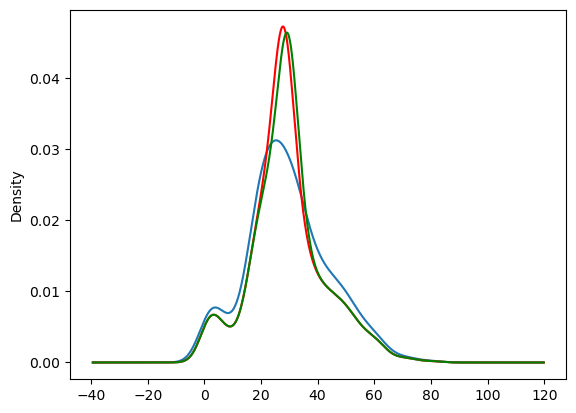

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

# orifinal variable distribution
X_train["Age"].plot(kind = 'kde', ax=ax)

# variable imputed with the median
X_train['Age_median'].plot(kind = "kde", ax=ax, color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind = "kde", ax=ax, color='green')

# add Legends
line, labels = ax.get_legend_handles_lables()
ax.legend(lines, lables, loc="best")

In [26]:
X_train.cov()

,Age,SibSp,Fare,Age_mean,Age_median
Age,210.251707,-4.501273,71.580633,210.251707,210.251707
SibSp,-4.501273,1.383927,9.354652,-3.614946,-3.637141
Fare,71.580633,9.354652,2700.831981,57.485994,61.261919
Age_mean,210.251707,-3.614946,57.485994,168.851934,168.851934
Age_median,210.251707,-3.637141,61.261919,168.851934,169.207310


In [27]:
X_train.corr()


,Age,SibSp,Fare,Age_mean,Age_median
Age,1.000000,-0.320916,0.088103,1.000000,1.000000
SibSp,-0.320916,1.000000,0.153011,-0.236479,-0.237681
Fare,0.088103,0.153011,1.000000,0.085126,0.090622
Age_mean,1.000000,-0.236479,0.085126,1.000000,0.998949
Age_median,1.000000,-0.237681,0.090622,0.998949,1.000000


<Axes: >

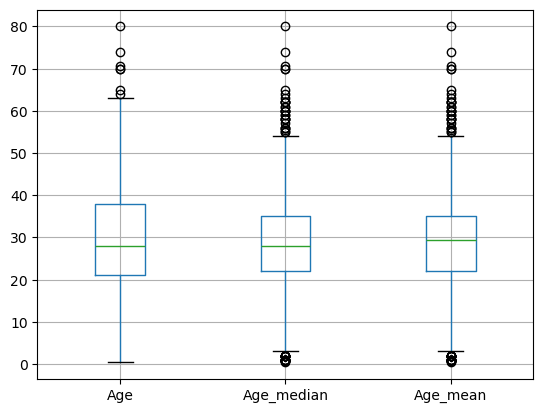

In [28]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

in above work done this is not what we need. it is competly a red flag 
we should not use in our work this way.

# Using Sklearn

In [29]:
X_trsin, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [30]:
imputer1 = SimpleImputer(strategy = "median")
imputer2 = SimpleImputer(strategy = "mean")

In [42]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Age'])
],remainder='passthrough')

In [43]:
trf.fit(X_train)

ValueError: Specifying the columns using strings is only supported for dataframes.

In [39]:
trf.named_transformers_['imputer1'].statistics_

array([28.])

In [40]:
trf.named_transformers_['imputer2'].statistics_

array([32.58627612])

In [41]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

ValueError: columns are missing: {'Age_median', 'Age_mean'}

# Arbitrary value Implutation
Filling missing values with a fixed unusual value like -9999, -1, or 0.

## Why use it?
* Keeps all data
* Helps models like decision trees learn that a value was missing
* Easy to implement

## When not to use?
Avoid with KNN or Linear Regression (can affect accuracy)

In [36]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='constant', fill_value=-9999)
df[['Age']] = imputer.fit_transform(df[['Age']])

# End of Distribution Imputation
Replacing missing values with a very high or very low value that lies at the end of the variable's distribution (but still realistic).

## Why use it?
* Makes the missing values stand out
* Helps tree-based models (like Random Forest) recognize patterns
* Better than arbitrary if you want the value to still "fit" the data range

## How to do it?
Pick a value beyond the max or min. Example:
Use `max + 1` or `Q3 + 1.5 * IQR` (if right-skewed).